## Embeddings pour le texte et l’image

## 1. Préparation

**Cette partie est à exécuter en premier, de façon à télécharger les
bibliothèques, les données et les modèles nécessaires pour la suite du
TP**.

### Installation des bibliothèques (choisir l'une des options)

**Option 1** (solution propre mais un peu plus complexe, passez à
l'option 2 si vous ne comprenez rien)

1.  Si vous n'avez jamais utilisé `uv`, suivez les instructions
    d'installation ici
    <https://docs.astral.sh/uv/getting-started/installation/> (dans
    votre terminal, pas dans le notebook).
2.  Télécharger le fichier
    [`pyproject.toml`](https://schwander.isir.upmc.fr/enseignement/m2probafi_apprentissage/pyproject.toml)
    sur la page du cours.
3.  Mettre à jour l'environnement Python avec `uv sync` (dans votre
    terminal, pas dans le notebook).
4.  Fermer ce notebook et relancez Jupyter avec la commande
    `uv run jupyter notebook` (dans votre terminal, attention à bien
    être dans le répertoire avec le fichier `pyproject.toml`).

**Option 2** (à utiliser notamment avec Google Colab)

Copier-coller ce qui suit dans une cellule de ce notebook et exécuter
cette cellule:

    !pip install --index-url https://download.pytorch.org/whl/cpu "torch>=2.9.0"
    !pip install --index-url https://download.pytorch.org/whl/cpu "torchaudio>=2.9.0"
    !pip install --index-url https://download.pytorch.org/whl/cpu "torchvision>=0.24.0"
    !pip install "bitsandbytes>=0.48.2"
    !pip install "datasets>=4.4.1"
    !pip install "evaluate>=0.4.6"
    !pip install "gensim>=4.4.0"
    !pip install "jupyter>=1.1.1"
    !pip install "mlflow>=3.6.0"
    !pip install "nltk>=3.9.2"
    !pip install "peft>=0.18.0"
    !pip install "polars>=1.35.1"
    !pip install "rouge-score>=0.1.2"
    !pip install "transformers>=4.57.3"
    !pip install "trl>=0.25.1"
    !pip install "pytorch-lightning>=2.6.0"
    !pip install "open-clip-torch>=3.2.0"

### Téléchargements des modèles et des datasets (exécuter ce qui suit)

In [46]:
from tqdm import tqdm
import torch
from datasets import load_dataset
import open_clip
from PIL import Image
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

**Modèle OpenCLIP pré-entraîné**

In [3]:
model, _, preprocess = open_clip.create_model_and_transforms('ViT-B-32', pretrained='laion2b_s34b_b79k')
tokenizer = open_clip.get_tokenizer('ViT-B-32')
model.eval()

open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

CLIP(
  (visual): VisionTransformer(
    (conv1): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)
    (patch_dropout): Identity()
    (ln_pre): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (transformer): Transformer(
      (resblocks): ModuleList(
        (0-11): 12 x ResidualAttentionBlock(
          (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (ls_1): Identity()
          (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): Sequential(
            (c_fc): Linear(in_features=768, out_features=3072, bias=True)
            (gelu): GELU(approximate='none')
            (c_proj): Linear(in_features=3072, out_features=768, bias=True)
          )
          (ls_2): Identity()
        )
      )
    )
    (ln_post): LayerNorm((768,), eps=1e-05, elementwise_affine

**Dataset CIFAR10**

In [16]:
# On a besoin du nom des classes
cifar10_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

cifar10 = load_dataset("cifar10")
cifar10_test = cifar10["test"].shuffle().take(1000)
cifar10_test

Dataset({
    features: ['img', 'label'],
    num_rows: 1000
})

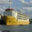

In [20]:
cifar10_test[100]["img"]

In [21]:
cifar10_test[100]["label"], cifar10_classes[cifar10_test[100]["label"]]

(8, 'ship')

**Dataset Stanford Dogs**

In [65]:
dogs_classes = [ "Affenpinscher", "Afghan hound", "African hunting dog", "Airedale", "American Staffordshire terrier", "Appenzeller", "Australian terrier", "Basenji", "Basset", "Beagle", "Bedlington terrier", "Bernese mountain dog", "Black-and-tan coonhound", "Blenheim spaniel", "Bloodhound", "Bluetick", "Border collie", "Border terrier", "Borzoi", "Boston bull", "Bouvier des Flandres", "Boxer", "Brabancon griffon", "Briard", "Brittany spaniel", "Bull mastiff", "Cairn", "Cardigan", "Chesapeake Bay retriever", "Chihuahua", "Chow", "Clumber", "Cocker spaniel", "Collie", "Curly-coated retriever", "Dandie Dinmont", "Dhole", "Dingo", "Doberman", "English foxhound", "English setter", "English springer", "EntleBucher", "Eskimo dog", "Flat-coated retriever", "French bulldog", "German shepherd", "German short-haired pointer", "Giant schnauzer", "Golden retriever", "Gordon setter", "Great Dane", "Great Pyrenees", "Greater Swiss Mountain dog", "Groenendael", "Ibizan hound", "Irish setter", "Irish terrier", "Irish water spaniel", "Irish wolfhound", "Italian greyhound", "Japanese spaniel", "Keeshond", "Kelpie", "Kerry blue terrier", "Komondor", "Kuvasz", "Labrador retriever", "Lakeland terrier", "Leonberg", "Lhasa", "Malamute", "Malinois", "Maltese dog", "Mexican hairless", "Miniature pinscher", "Miniature poodle", "Miniature schnauzer", "Newfoundland", "Norfolk terrier", "Norwegian elkhound", "Norwich terrier", "Old English sheepdog", "Otterhound", "Papillon", "Pekinese", "Pembroke", "Pomeranian", "Pug", "Redbone", "Rhodesian ridgeback", "Rottweiler", "Saint Bernard", "Saluki", "Samoyed", "Schipperke", "Scotch terrier", "Scottish deerhound", "Sealyham terrier", "Shetland sheepdog", "Shih-Tzu", "Siberian husky", "Silky terrier", "Soft-coated wheaten terrier", "Staffordshire bullterrier", "Standard poodle", "Standard schnauzer", "Sussex spaniel", "Tibetan mastiff", "Tibetan terrier", "Toy poodle", "Toy terrier", "Vizsla", "Walker hound", "Weimaraner", "Welsh springer spaniel", "West Highland white terrier", "Whippet", "Wire-haired fox terrier", "Yorkshire terrier" ]

dogs = load_dataset("Donghyun99/Stanford-Dogs")
dogs = dogs["test"].shuffle().take(1000)

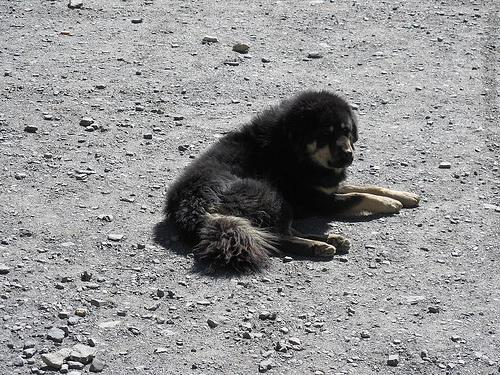

In [66]:
dogs[8]["image"]

In [67]:
dogs_classes[dogs[8]["label"]]

'Leonberg'

## 2. Classification avec CLIP

### Architecture

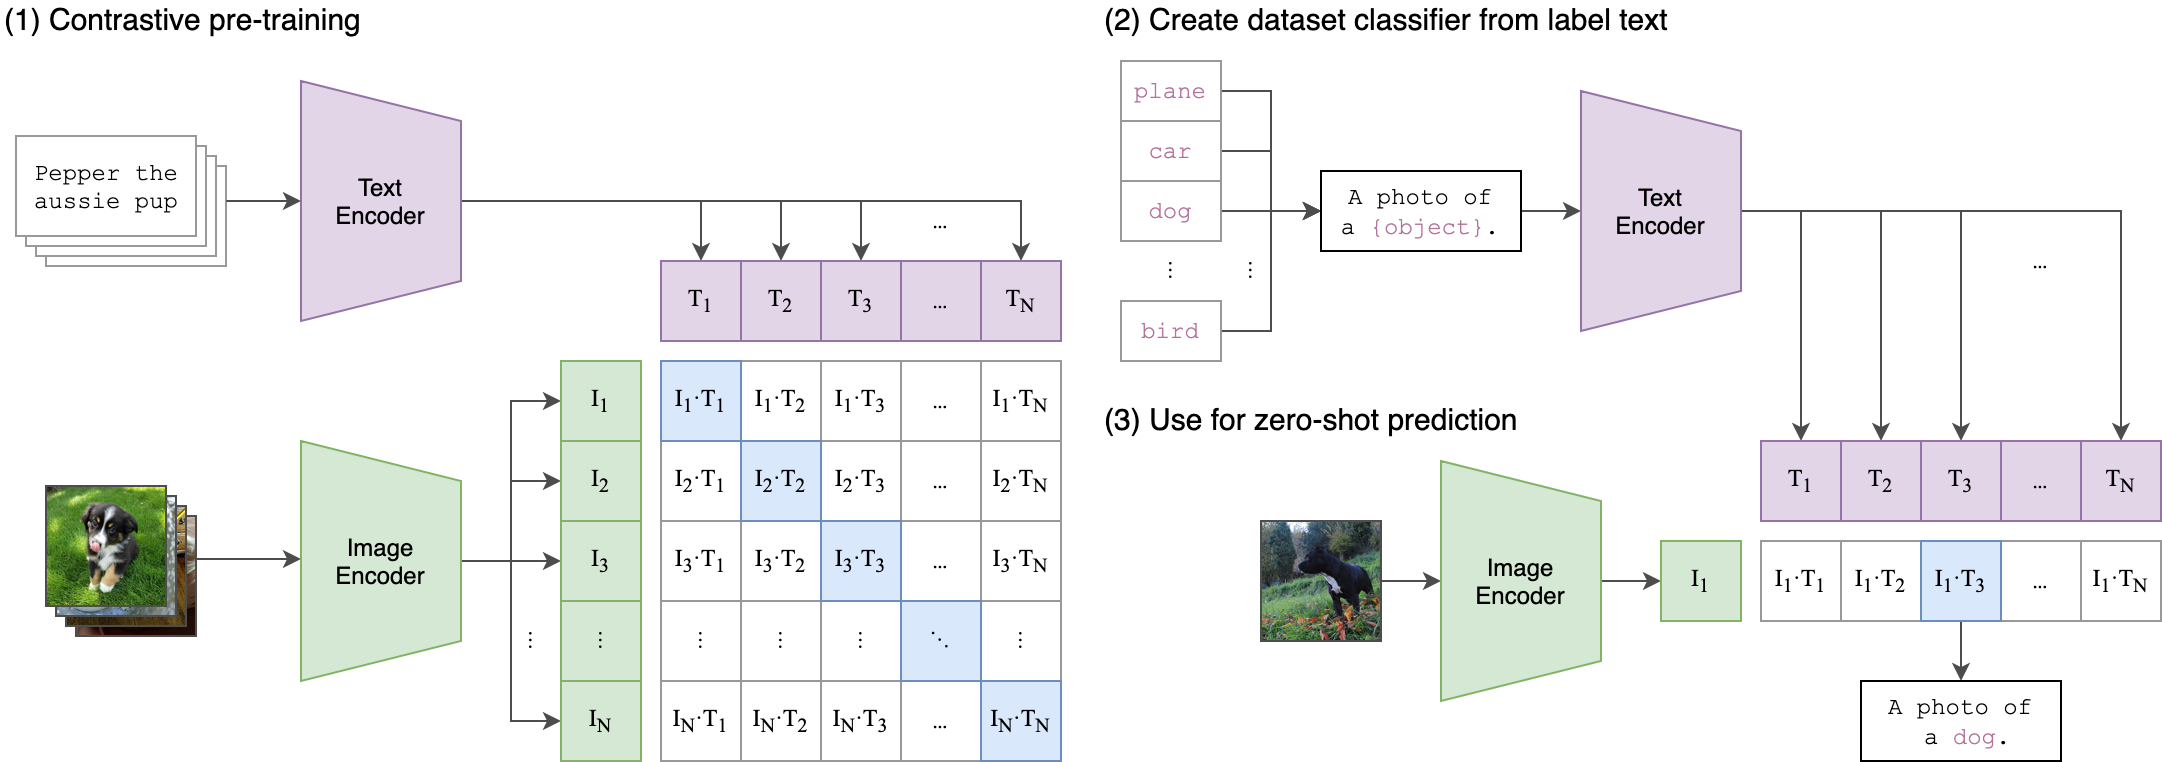

### Classification Zero-Shot

CLIP peut réaliser des tâches de classification sans avoir vu ni les classes ni les exemples durant l'entraînement, et sans fine-tuning. Le processus est le suivant:

- Définition des classes sous forme textuelle ("chien", "chat", etc), on n'utilise plus seulement des numéros
- Calcul des représentations de ces classes
- Calcul de la représentation de l'image à classer
- Comparaison de l'image avec chacune des classes (avec la distance cosine)
- Choix de la classe associée au score le plus élevé


### Classification CIFAR10

On doit commencer par calculer la représentation des différentes classes. Remarquez le template utilisé ici: on ne calcule pas l'embedding de "airplaine" mais de la phrase "a photo of an airplaine", on verra tout à l'heure l'impact de ce choix sur les performances.

In [22]:
# Class template
template = "a photo of a {}"

# Encode text labels
text_inputs = tokenizer([template.format(c) for c in classes])
with torch.no_grad():
    text_features = model.encode_text(text_inputs)
    text_features /= text_features.norm(dim=-1, keepdim=True)

In [30]:
correct = 0
total = 0
predictions = []
true_labels = []

for example in tqdm(cifar10_test):
    # Preprocess image
    image = preprocess(example["img"]).unsqueeze(0)
    
    # Encode image
    with torch.no_grad():
        image_features = model.encode_image(image)
        image_features /= image_features.norm(dim=-1, keepdim=True)
        
        # Calculate similarity
        similarity = (image_features @ text_features.T).squeeze(0)
        prediction = similarity.argmax().item()

    predictions.append(prediction)
    true_labels.append(example["label"])

    if prediction == example["label"]: 
        correct += 1
    total += 1

# Print accuracy
accuracy = 100 * correct / total
print(f"Accuracy: {accuracy:.2f}%")

100%|█████████████████████████████████████████████████████████████████| 1000/1000 [00:41<00:00, 23.98it/s]

Accuracy: 93.90%


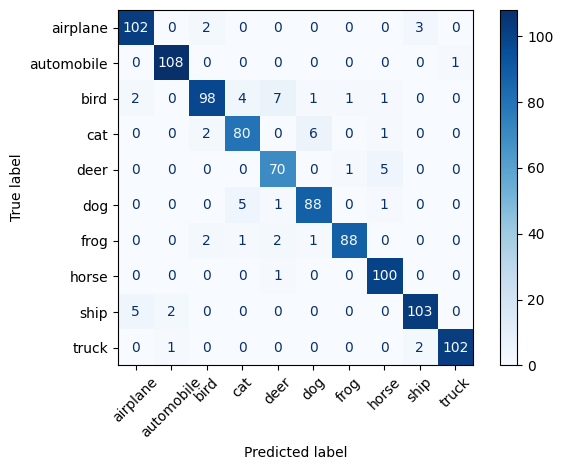

In [32]:
cm = confusion_matrix(true_labels, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.tight_layout()
plt.show()

**Question** Essayez avec d'autres prompts et comparer les scores. Quelques idées possibles:
- les noms des classes seuls
- des variantes "a picture of", "an image of", "a photo a"
- des version françaises, avec ou sans "une photo de"
- des détails rajoutés "a picture of a truck, a type of vehicle"

### Classification fine-grained

On veut maintenant évaluer la capacité du modèle à fonctionner en zero-shot sur des classes beaucoup plus précises (car les classes à la ImageNet ou à la CIFAR sont rarement intéressantes en pratique).

**Question** Sur le dataset *Stanford Dogs*, omparez les performances entre les deux templates suivants:
- "a picture of {}"
- et des prompts enrichis basés sur la description des races de chiens:
    - "a photo of a Chihuahua, a very small dog with large ears",
    - "a photo of a Labrador Retriever, a medium to large dog",
    - "a photo of a German Shepherd, a large dog with pointed ears",
    - on peut se limiter à ces trois classes ou compléter avec Wikipedia ou un chatbot quelconque.

## 3. Recherche d'information

### Indexation vectorielle

Les embeddings peuvent être utilisés comme index. Dans ce cas, une recherche par plus proche voisin permet de chercher des images similaires à une requête. Comme l'espace latent est commun entre le texte et l'image, on peut faire une recherche avec une requête visuelle ou une requête textuelle.

L'index peut être stocké dans une base de données vectorielles, permettant de faire la recherche efficacement en utilisant le plus proche voisin ou le plus proche voisin approché (voir par exemple [FAISS](https://faiss.ai) ou [Chroma](https://docs.trychroma.com/docs/overview/getting-started)).

Dans un souci de simplicité, on stockera ici les embeddings dans un simple tenseur et on fera la recherche à la main.

**Question** Calculer les embeddings d'une centaine d'images de CIFAR10 et stocker les vecteurs dans une matrice numpy ou un tenseur torch.

**Question** En parcourant manuellement l'index, cherchez l'image la plus similaire à une requête sous forme d'image.

**Question** En parcourant manuellement l'index, cherchez l'image la plus similaire à une requête sous forme de texte.

**Question bonus** Mettez en place un protocole d'évaluation

**Question bonus** Avec la bibliothèque [Streamlit](https://streamlit.io) construisez une petite application web de démonstration.

## 4. Retrieval-Augmented Generation (RAG) pour le question answering

### Embeddings de documents

Dans les modèles RAG, on utilise une source de données externes pour enrichir le contexte d'un chatbot, ce qui permet d'améliorer la réponse à un prompt. Cette source de données externes peut être par exemple:
- une base de données relationnelle;
- une recherche sur le web;
- un accès aux fichiers locaux de l'utilisateur;
- un accès à un index dense avec un encodeur textuel.

Les techniques d'agents rentrent aussi en partie dans cette catégorie.

Même si CLIP permet de représenter des documents textuels, ce modèle n'est pas conçu pour des documents complexes. On utilisera plutôt des modèles dédiés, dits *encoder-only* (des modèles de langues qui calculent une représentation mais ne sont pas prévus pour la génération):
- des modèles génériques comme BERT et Sentence-BERT
- des modèles spécialisés comme [`facebook/dpr-question_encoder-single-nq-base`](https://huggingface.co/sentence-transformers/facebook-dpr-question_encoder-single-nq-base) (utilisé dans la suite)


### Motivation

**Question** (à faire sur [LMArena](https://lmarena.ai/fr?mode=side-by-side)) Demandez à un chatbot la date de naissance d'Harrisson Ford. Demandez-lui votre date de naissance. Que se passe-t-il et pourquoi ?

**Question** Comment faire pour injecter ses propres connaissances dans le LLM ?

**Question** Essayez d'injecter des connaissances dans le prompt du LLM. À quel point peut-on augmenter le nombre de connaissances ?

Même si cette approche ne passe pas à l'échelle, elle est parfaitement utilisable avec un faible nombre d'informations. Essayez par exemple le prompt suivant:

```
Answer only with the following context:
- Harrisson Ford is an American actor
- Harrisson Ford was born in 1942
- Harrisson Ford portrayed Indiana Jones

How old is Harrisson Ford ?
```

**Question** Comment s'assurer que le modèle utilise bien nos connaissances et pas sa culture générale ?

### Architecture

Un système RAG est consitué en général des étapes suivantes:

1. Interprétation de la requête utilisateur (une question en langue
   naturelle, ou de simples mots-clés)
1. Construction d'une requête vers une base de données (vectorielle,
   ou même relationnelle)
1. Récupération des résultats depuis la base de données
1. Construction de la réponse finale

On s'intérese dans cette partie à un système de question-réponse. Les
questions viendront du dataset
[NQ-Open](https://huggingface.co/datasets/google-research-datasets/nq_open)
(ne pas le télécharger ! Regarder simplement quelques exemples).  Les
questions de ce dataset ont la particularité d'avoir toutes leur
réponse dans Wikipedia. Notre base de données sera donc un index
vectoriel des articles de l'encyclopédie (découpés en fragments d'une
centaine de mots).

Les étapes du système RAG deviennent donc:

|  Cas général | Notre exemple |
|--------------------------------|------------------------------------------------------------------------------------------|
| Interprétation de la question | Calcul d'un embedding |
| Requête dans la base de donnée | Plus proche voisin dans la base de données vectorielle|
| Récupération des résultats | Phrases issues d'articles |
| Génération de la réponse | Construction d'un prompt avec les les fragments d'artices et la question, puis exécution |

On utilisera un modèle pré-entraîné et précalculé à partir de
Wikipedia. Voir <https://huggingface.co/datasets/facebook/wiki_dpr>
(Ne pas le télécharger ! Regarder simplement.)

Le contenu de Wikipedia, l'index précalculé ou même les poids du
modèle d'embedding sont beaucoup trop gros pour être manipulés sur une
machine personnelle (plusieurs centaines de Go de stogage et plusiers
dizaines de Go de mémoire) et la recherche serait de toute façon
beaucoup trop lente pour être utilisable. De façon à construire un RAG
sur Wikipedia et non sur un petit jouet, nous allons donc tricher.

On va utiliser des résultats de recherche précalculés: les seules
questions possibles seront donc celles connues lors du
précalcul. C'est le rôle du module *fakesearch* à télécharger.

Fichiers à télécharger:

- [fakesearch.py](https://schwander.isir.upmc.fr/enseignement/m2probafi_apprentissage/fakesearch.py)
- [faiss-validation.pickle](https://schwander.isir.upmc.fr/enseignement/m2probafi_apprentissage/faiss-validation.pickle)

Pour une question connue, on peut accéder aux fragments wikipedia les
plus pertinents de la façon suivante:

In [ ]:
import fakesearch

dense_index = fakesearch.load("faiss-validation.pickle")
dense_index["what is a lobster roll"]

Bien sûr, si la question n'était pas connue à l'avance, on obtiendra
une erreur dans le cas contraire:

In [ ]:
dense_index["How old is Harrison Ford"]

**Question** À partir d'une question, récupérez la liste des fragment wikipedia pertinents.

**Question** Construisez un système de réponse aux questions.